In [9]:
from project.utilities.simulation import run_trials, run_task, run_experiments, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
from numpy.random import default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap

import pandas as pd


# For displaying
from IPython.display import display

# Change font of plots
use_latex_fonts()

This notebook is dedicated to to illustrate the effect of cortical processing on accuracy. To this end, the minimal coherence level resulting in $95\%$ accuracy will be extracted for across strength and noise conditions. This coherence level will be called the *lowest passing coherence*

# Import Data

In [10]:
summary_stats1 = load_results('suite1_summary.csv', '../../data/cortical dynamics') 
summary_stats_bypass1 = load_results('suite1_bypass_summary.csv', '../../data/cortical dynamics')

summary_stats2 = load_results('suite2_summary.csv', '../../data/cortical dynamics') 
summary_stats_bypass2 = load_results('suite2_bypass_summary.csv', '../../data/cortical dynamics')

# Extra generated data, as explained below
summary_stats_bypass_supplementary = load_results('cortical_processing_SvC_summary.csv', '../../data')


Loaded: ..\..\data\cortical dynamics\suite1_summary.csv
Loaded: ..\..\data\cortical dynamics\suite1_bypass_summary.csv
Loaded: ..\..\data\cortical dynamics\suite2_summary.csv
Loaded: ..\..\data\cortical dynamics\suite2_bypass_summary.csv
Loaded: ..\..\data\cortical_processing_SvC_summary.csv


Initially, the plot showed that the lowest passing coherence for strength levels $\mu_0 = 0.4$ and $\mu_0 = 0.6$ was $100\%$ without the cortex. This was not particularly representative, however, as coherence levels between $30\%$ and $100\%$ were not tested. Thus, additional trials were run to get a higher resolution. Quickly visualizing the extra data

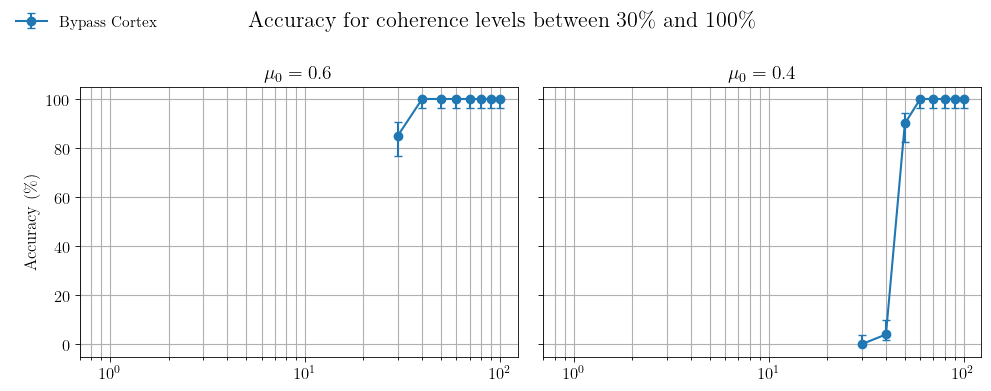

In [11]:
# ===== Split data by strength level =====
# Summary stats
df_08 = summary_stats_bypass_supplementary[summary_stats_bypass_supplementary['strength'] == 0.6]
df_06 = summary_stats_bypass_supplementary[summary_stats_bypass_supplementary['strength'] == 0.4]

# --- Accuracy ---
acc_08, acc_err_08 = get_CI(df_08, metric='Accuracy (%)') 
acc_06, acc_err_06 = get_CI(df_06, metric='Accuracy (%)') 

# ==== Plotting ====
coherences = summary_stats_bypass_supplementary['coherence'].unique()*100
fig, ax = plt.subplots(1,  2,  figsize= (figure_size('single')), subplot_kw={"xscale": "log"}, sharex = True, sharey = 'row')

ax[0].errorbar(x = coherences, y = acc_08, yerr = acc_err_08, fmt='o-', capsize = 3, markersize = 6, label='Bypass Cortex')
ax[0].set_title('$\mu_0 = 0.6$')
ax[0].set_ylabel('Accuracy (\%)')
ax[0].grid(which = 'both')

ax[1].errorbar(x = coherences, y = acc_06, yerr = acc_err_06, fmt='o-', capsize = 3, markersize = 6)
ax[1].set_title('$\mu_0 = 0.4$')
ax[1].grid(which = 'both')


ax[1].set_xlim(left = 0.7)
ax[1].set_ylim(-5, 105)

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy for coherence levels between $30\%$ and $100\%$')
plt.tight_layout()
plt.show()

# Lowest Passing Coherences


Finding the lowest coherence level to result in at least $95\%$ accuracy

First, combining dataframes:

In [12]:
summary_stats_combined = pd.concat(
    [
        summary_stats1.assign(source="suite1"),
        summary_stats2.assign(source="suite2"),
    ],
    ignore_index=True
)

summary_stats_bypass_combined = pd.concat(
    [
        summary_stats_bypass1.assign(source="suite1_bypass"),
        summary_stats_bypass2.assign(source="suite2_bypass"),
    ],
    ignore_index=True
)

display(summary_stats_combined.head())
display(summary_stats_bypass_combined.head())



,coherence,noise_std,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin,source,strength
0,1.0,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,49.44,0.24,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0,suite1,NaN
1,1.0,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,49.45,0.25,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0,suite1,NaN
2,1.0,0.500,100.0,0.0,96.3,100.0,-7.13,7.13,49.82,0.26,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0,suite1,NaN
3,0.3,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,62.54,0.35,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0,suite1,NaN
4,0.3,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,62.85,0.58,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0,suite1,NaN


,coherence,noise_std,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin,source,strength
0,1.0,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,37.58,0.25,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000,suite1_bypass,NaN
1,1.0,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,38.00,0.30,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000,suite1_bypass,NaN
2,1.0,0.500,100.0,0.0,96.3,100.0,-7.13,7.13,38.38,0.41,...,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000,suite1_bypass,NaN
3,0.3,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,46.75,0.60,...,100.0,0.0,0.0,0.0,0.0,3.7,0.048,0.002,suite1_bypass,NaN
4,0.3,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,48.93,1.37,...,100.0,0.0,0.0,0.0,0.0,3.7,0.070,0.002,suite1_bypass,NaN


### Functions for extracting lowest passing coherence

In [13]:
import numpy as np
import pandas as pd


def get_lowest_passing_thresholds(
    df,
    level_col,
    condition_name,
    suite_name,
    coherence_col="coherence",
    accurate_col="Accuracy (%)",
    accuracy_cutoff=95,
):
    """
    For each level, find the lowest tested coherence where mean accuracy
    reaches accuracy_cutoff.

    Assumes coherence is stored as a fraction:
        0.01 = 1%
        0.1  = 10%
    """

    data = df.copy()

    data["coherence_pct"] = data[coherence_col] * 100

    accuracy_table = (
        data
        .groupby([level_col, "coherence_pct"])[accurate_col]
        .mean()
        .reset_index(name="accuracy_pct")
        .sort_values([level_col, "coherence_pct"])
    )

    # Convert fractions/booleans to percent.
    already_percent = "%" in accurate_col or "pct" in accurate_col.lower()
    if not already_percent and accuracy_table["accuracy_pct"].dropna().max() <= 1:
        accuracy_table["accuracy_pct"] *= 100


    rows = []

    for level_value, group in accuracy_table.groupby(level_col):
        group = group.sort_values("coherence_pct")

        passing = group[group["accuracy_pct"] >= accuracy_cutoff]

        if len(passing) > 0:
            lowest_row = passing.iloc[0]

            rows.append({
                "suite": suite_name,
                "level_parameter": level_col,
                "level_value": level_value,
                "condition": condition_name,
                "lowest_passing_coherence_pct": lowest_row["coherence_pct"],
            })

        else:
            rows.append({
                "suite": suite_name,
                "level_parameter": level_col,
                "level_value": level_value,
                "condition": condition_name,
                "lowest_passing_coherence_pct": np.nan,
            })

    return pd.DataFrame(rows), accuracy_table

In [14]:
def compare_lowest_passing_coherence(
    with_cortex_noise_df,
    bypass_cortex_noise_df,
    with_cortex_strength_df,
    bypass_cortex_strength_df,
    bypass_cortex_strength_supplement_df=None,
    noise_level_col="sigma",
    strength_level_col="mu0",
    coherence_col="coherence",
    accurate_col="Accurate",
    accuracy_cutoff=95,
):
    """
    Computes the lowest passing coherence values for With Cortex and
    Bypass Cortex across both experiment suites.
    """

    # Noise suite
    noise_with, _ = get_lowest_passing_thresholds(
        df=with_cortex_noise_df,
        level_col=noise_level_col,
        condition_name="With Cortex",
        suite_name="Noise",
        coherence_col=coherence_col,
        accurate_col=accurate_col,
        accuracy_cutoff=accuracy_cutoff,
    )

    noise_bypass, _ = get_lowest_passing_thresholds(
        df=bypass_cortex_noise_df,
        level_col=noise_level_col,
        condition_name="Bypass Cortex",
        suite_name="Noise",
        coherence_col=coherence_col,
        accurate_col=accurate_col,
        accuracy_cutoff=accuracy_cutoff,
    )

    # Strength suite
    if bypass_cortex_strength_supplement_df is not None:
        bypass_cortex_strength_df = pd.concat(
            [bypass_cortex_strength_df, bypass_cortex_strength_supplement_df],
            ignore_index=True,
        )

    strength_with, _ = get_lowest_passing_thresholds(
        df=with_cortex_strength_df,
        level_col=strength_level_col,
        condition_name="With Cortex",
        suite_name="Strength",
        coherence_col=coherence_col,
        accurate_col=accurate_col,
        accuracy_cutoff=accuracy_cutoff,
    )

    strength_bypass, _ = get_lowest_passing_thresholds(
        df=bypass_cortex_strength_df,
        level_col=strength_level_col,
        condition_name="Bypass Cortex",
        suite_name="Strength",
        coherence_col=coherence_col,
        accurate_col=accurate_col,
        accuracy_cutoff=accuracy_cutoff,
    )

    thresholds_long = pd.concat(
        [
            strength_with,
            strength_bypass,
            noise_with,
            noise_bypass,
        ],
        ignore_index=True,
    )

    comparison = (
        thresholds_long
        .pivot_table(
            index=["suite", "level_parameter", "level_value"],
            columns="condition",
            values="lowest_passing_coherence_pct",
            aggfunc="first",
        )
        .reset_index()
    )

    comparison = comparison.rename(
        columns={
            "With Cortex": "with_cortex_threshold_pct",
            "Bypass Cortex": "bypass_cortex_threshold_pct",
        }
    )
    comparison.columns.name = None

    comparison = comparison.sort_values(
        ["suite", "level_value"],
        ascending=[False, True],
    )

    return comparison, thresholds_long

### Get lowest passing coherences

In [15]:
comparison, thresholds_long = compare_lowest_passing_coherence(
    with_cortex_noise_df=summary_stats1,
    bypass_cortex_noise_df=summary_stats_bypass1,
    with_cortex_strength_df=summary_stats2,
    bypass_cortex_strength_df=summary_stats_bypass2,
    bypass_cortex_strength_supplement_df=summary_stats_bypass_supplementary,

    noise_level_col="noise_std",
    strength_level_col="strength",

    coherence_col="coherence",
    accurate_col="Accuracy (%)",

    accuracy_cutoff=95,
)

comparison

,suite,level_parameter,level_value,bypass_cortex_threshold_pct,with_cortex_threshold_pct
3,Strength,strength,0.400,60.0,30.0
4,Strength,strength,0.600,40.0,8.0
5,Strength,strength,0.800,30.0,8.0
0,Noise,noise_std,0.125,15.0,5.0
1,Noise,noise_std,0.250,10.0,5.0
2,Noise,noise_std,0.500,8.0,8.0


### Plotting lowest passing coherences

Saved: ..\..\figures\comparison\Cortical Dynamics - Lowest Passing Coherence.pdf
Saved: ..\..\figures\comparison\Cortical Dynamics - Lowest Passing Coherence.png


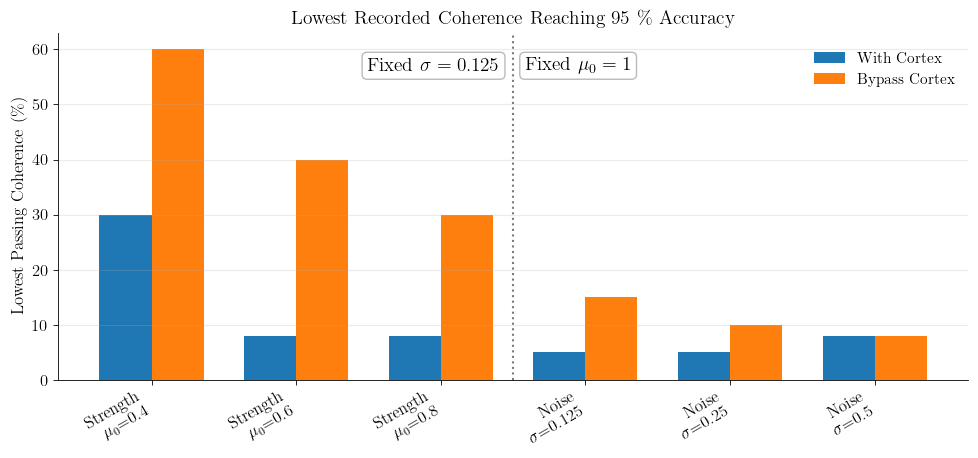

In [17]:
import matplotlib.pyplot as plt


def plot_direct_threshold_comparison(
    comparison,
    title="Lowest Recorded Coherence Reaching 95 \% Accuracy",
):
    plot_df = comparison.copy()

    parameter_labels = {
        "strength": r"$\mu_0$",
        "mu0": r"$\mu_0$",
        "noise_std": r"$\sigma$",
        "sigma": r"$\sigma$",
    }

    labels = [
        f"{row.suite}\n{parameter_labels.get(row.level_parameter, row.level_parameter)}={row.level_value:g}"
        for row in plot_df.itertuples()
    ]

    x = np.arange(len(plot_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 4.8))

    ax.bar(
        x - width / 2,
        plot_df["with_cortex_threshold_pct"],
        width,
        label="With Cortex",
    )

    ax.bar(
        x + width / 2,
        plot_df["bypass_cortex_threshold_pct"],
        width,
        label="Bypass Cortex",
    )
    suite_values = plot_df["suite"].to_numpy()
    suite_boundaries = np.where(suite_values[1:] != suite_values[:-1])[0] + 0.5

    for boundary in suite_boundaries:
        ax.axvline(
            boundary,
            color="0.35",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
            zorder=0,
        )
    box_style = dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.7",
        alpha=0.9,
    )

    ax.text(
        1.95,
        0.93,
        r"Fixed $\sigma = 0.125$",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        bbox=box_style,
    )

    ax.text(
        2.95,
        0.93,
        r"Fixed $\mu_0 = 1$",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        bbox=box_style,
    )


    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")

    ax.set_ylabel("Lowest Passing Coherence (\%)")
    ax.set_title(title)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.985))


    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    return fig, ax

fig, ax = plot_direct_threshold_comparison(comparison)

save_plot(fig, 'Cortical Dynamics - Lowest Passing Coherence', folder='../../figures/comparison', formats=('pdf', 'png'))